<a href="https://colab.research.google.com/github/Aadi2612/urban-rural-erosion-prediction/blob/main/notebooks/Urban_ML_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Index(['X', 'Y', 'fid', 'k_factor_aligned', 'soil_loss_4326',
       'lulc_chennai_clip_aligned', 'slope_chennai_clip_aligned',
       'ndvi_chennai_clip_aligned', 'dem_chennai_clip_aligned'],
      dtype='object')
               Model  R2 Score      RMSE
0  Linear Regression  0.124754  4.745144
1      Random Forest  0.343213  4.110518
2  Gradient Boosting  0.358503  4.062391


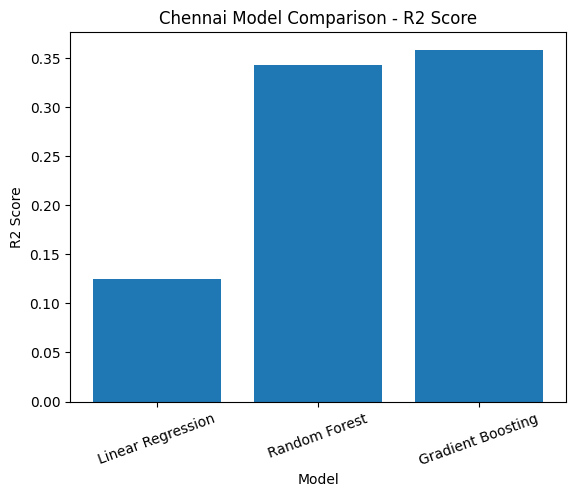

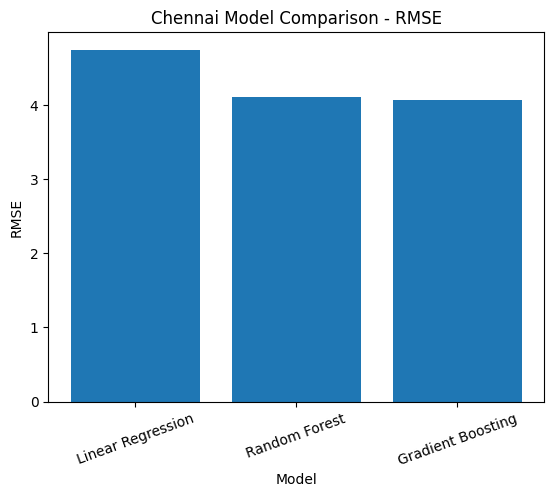

Best Model Selected: Gradient Boosting


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error

# Load Chennai dataset
df = pd.read_csv("Chennai_RUSLE_ml.csv")

print(df.columns)  # always good to verify

# Define feature columns EXACTLY as in your CSV
features = [
    "dem_chennai_clip_aligned",
    "k_factor_aligned",
    "lulc_chennai_clip_aligned",
    "slope_chennai_clip_aligned",
    "ndvi_chennai_clip_aligned"
]

X = df[features]
y = df["soil_loss_4326"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = []

# Train and evaluate
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append([name, r2, rmse])

results_df = pd.DataFrame(results, columns=["Model", "R2 Score", "RMSE"])
print(results_df)

# Plot R2
plt.figure()
plt.bar(results_df["Model"], results_df["R2 Score"])
plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.title("Chennai Model Comparison - R2 Score")
plt.xticks(rotation=20)
plt.show()

# Plot RMSE
plt.figure()
plt.bar(results_df["Model"], results_df["RMSE"])
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title("Chennai Model Comparison - RMSE")
plt.xticks(rotation=20)
plt.show()

# Select best model
best_model_name = results_df.sort_values("R2 Score", ascending=False).iloc[0]["Model"]
best_model = models[best_model_name]

print("Best Model Selected:", best_model_name)

# Train best model on full dataset
best_model.fit(X, y)

# Predict
df["soil_loss_pred"] = best_model.predict(X)

# Export predictions
output = df[["fid", "soil_loss_pred"]]
output.to_csv("chennai_predictions.csv", index=False)